<a href="https://colab.research.google.com/github/Ashish2343/R-MoE-Architecture-Comparisions/blob/main/Hierarchial_Improved_Addaptive_Incremental_Hoeffding_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
! pip install river

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 24.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [ ]:
import  pandas as pd
import numpy as np
from river import compose, tree, metrics, preprocessing, stream, utils, datasets, drift
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from scipy.integrate import simpson
import random
from scipy.stats import linregress

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI Reasearch/CICIDS/Incremental01/final_data1.csv')

In [ ]:
df['Label'].value_counts()

,count
Label,
BENIGN,200000
DoS,100000
PortScan,60000
DDoS,60000
BruteForce,13832
Bot,1900


In [ ]:
group = {
    'BENIGN':'0',
    'DoS': '0',
    'PortScan': '0',
    'Bot': '1',
    'DDoS': '1',
    'BruteForce': '1'
}

In [ ]:
df['Group'] = df['Label'].map(group)

In [ ]:
label_encoder = LabelEncoder()
df["Label_encoded"] = label_encoder.fit_transform(df["Label"])

df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
df.drop(['Label'], axis=1, inplace=True)

In [ ]:
df_012 = df[df['Label_encoded'].isin([0, 1, 2])]
df_345 = df[df['Label_encoded'].isin([3, 4, 5])]

In [ ]:
sample_012 = df_012.sample(n=500, random_state=42)
sample_345 = df_345.sample(n=500, random_state=42)

In [ ]:
df_remaining = df.drop(sample_012.index).drop(sample_345.index)

In [ ]:
X_012 = sample_012.drop(columns=["Group", "Label_encoded"])
y_012 = sample_012["Label_encoded"]


x_345 = sample_345.drop(columns=["Group", "Label_encoded"])
y_345 = sample_345["Label_encoded"]


In [ ]:
X = df_remaining.drop(columns=["Group", "Label_encoded"])
y = df_remaining["Label_encoded"]

In [ ]:
df_remaining.shape

(434732, 79)

In [ ]:
ROUTER_CONFIDENCE_THRESHOLD = 0.65
PENALTY_FACTOR = 0.3
ROUTER_MARGIN = 0.10

In [ ]:
def predict_full_architecture(x_in):

    g_pred = baseline_model.predict_one(x_in)

    if g_pred is None: g_pred = 0 # Cold start handling

    if g_pred == 0:
        return expert_1.predict_one(x_in)
    elif g_pred == 1:
        return expert_2.predict_one(x_in)
    else:
        return expert_1.predict_one(x_in)

In [ ]:
def get_holdout_accuracy(dataset_list):
    """Calculates accuracy using the new Resilient Architecture."""
    val_metric = metrics.Accuracy()
    for x_val, y_val in dataset_list:
        # UPDATED: Use the new prediction function
        p_val = predict_resilient_architecture(x_val)
        if p_val is not None:
            val_metric.update(y_val, p_val)
    return val_metric.get()

In [ ]:
def combine_predictions(router_probs, pred_e1, pred_e2):

    final_preds = {}

    # 1. Get Router Weights
    w_g0 = router_probs.get(0, 0.0)
    w_g1 = router_probs.get(1, 0.0)

    margin = abs(w_g1 - w_g0)

    if margin > ROUTER_MARGIN:
        penalty_e1 = PENALTY_FACTOR if w_g1 > w_g0 else 1.0
        penalty_e2 = PENALTY_FACTOR if w_g0 > w_g1 else 1.0
    else:
        # If the router is effectively guessing (e.g., 52% vs 48%), apply no penalty
        penalty_e1 = 1.0
        penalty_e2 = 1.0

    # 3. Add Expert 1 contributions (With Penalty)
    # Score = Confidence * RouterWeight * Suppression

    for label, conf in pred_e1.items():
        score = conf * w_g0 * penalty_e1
        final_preds[label] = final_preds.get(label, 0.0) + score

    # 4. Add Expert 2 contributions (With Penalty)
    for label, conf in pred_e2.items():
        score = conf * w_g1 * penalty_e2
        final_preds[label] = final_preds.get(label, 0.0) + score

    if not final_preds: return 0
    return max(final_preds, key=final_preds.get)

In [ ]:
def predict_resilient_architecture(x_in):
    # Get Probabilities from Router
    router_proba = baseline_model.predict_proba_one(x_in)

    if not router_proba:
        return expert_1.predict_one(x_in)

    # Find the confidence of the best group
    best_group = max(router_proba, key=router_proba.get)
    confidence = router_proba[best_group]

    #  HARD ROUTING
    if confidence >= ROUTER_CONFIDENCE_THRESHOLD:
        if best_group == 0:
            return expert_1.predict_one(x_in)
        else:
            return expert_2.predict_one(x_in)

    # SOFT ROUTING
    else:
        pred_e1 = expert_1.predict_proba_one(x_in)
        pred_e2 = expert_2.predict_proba_one(x_in)

        return combine_predictions(router_proba, pred_e1, pred_e2)

# No Drift Scaneario

In [ ]:
val_set_group_0 = list(stream.iter_pandas(X_012, y_012))
val_set_group_1 = list(stream.iter_pandas(x_345, y_345))

dataset_train = stream.iter_pandas(X, y)

In [ ]:
baseline_model = preprocessing.StandardScaler() | tree.HoeffdingAdaptiveTreeClassifier(
    grace_period=50,
    delta=1e-5,
    tau=0.05,
    drift_detector=drift.ADWIN(delta=0.002),
    seed=42
)


expert_1 = preprocessing.StandardScaler() | tree.HoeffdingAdaptiveTreeClassifier(
    grace_period=200,
    delta=1e-6,
    tau=0.08,
    leaf_prediction="mc",
    drift_detector=drift.ADWIN(delta=0.001),
    seed=42
)


expert_2 =  preprocessing.StandardScaler() | tree.HoeffdingAdaptiveTreeClassifier(
    grace_period=50,
    delta=1e-4,
    tau=0.1,
    leaf_prediction="nba",
    drift_detector=drift.ADWIN(delta=0.05),
    seed=42
)

In [ ]:
WINDOW_SIZE = 5000

acc_metric_1 = utils.Rolling(metrics.Accuracy(), window_size=WINDOW_SIZE)
kappa_metric_1 = utils.Rolling(metrics.CohenKappa(), window_size=WINDOW_SIZE)
rolling_macro_f1 = utils.Rolling(metrics.MacroF1(), window_size=WINDOW_SIZE)


max_acc_g0 = 0.0
max_acc_g1 = 0.0
forgetting_history = []

accuracy_values = []
kappa_values = []
rolling_macro_f1_values = []
timestamps_1 = []
steps = []

log_interval_1 = 1000

group_0_labels = {0, 1, 2}
group_1_labels = {3, 4, 5}

In [ ]:
log_interval_1 = 1000

for i, (x, y_true) in enumerate(dataset_train, start=1):

  y_pred = predict_resilient_architecture(x)

  if y_pred is not None:
    acc_metric_1.update(y_true, y_pred)
    kappa_metric_1.update(y_true, y_pred)
    rolling_macro_f1.update(y_true, y_pred)

  if(y_true in group_0_labels):
     true_group = 0
  else:
    true_group = 1

  baseline_model.learn_one(x, true_group)

  if(true_group == 0):
    expert_1.learn_one(x, y_true)
  else:
    expert_2.learn_one(x, y_true)


  if i % log_interval_1 == 0:


      if len(val_set_group_0) > 0 and len(val_set_group_1) > 0:
            current_acc_g0 = get_holdout_accuracy(val_set_group_0)
            current_acc_g1 = get_holdout_accuracy(val_set_group_1)
      else:
            current_acc_g0 = 0.0
            current_acc_g1 = 0.0

        # 2. Update Maximums (The "Peak" performance)
      if current_acc_g0 > max_acc_g0: max_acc_g0 = current_acc_g0
      if current_acc_g1 > max_acc_g1: max_acc_g1 = current_acc_g1

        # 3. Calculate Forgetting
      f_g0 = max(0, max_acc_g0 - current_acc_g0)
      f_g1 = max(0, max_acc_g1 - current_acc_g1)

      avg_forgetting = (f_g0 + f_g1) / 2
      forgetting_history.append(avg_forgetting)

        # 4. Logging
      steps.append(i)
      accuracy_values.append(acc_metric_1.get())
      kappa_values.append(kappa_metric_1.get())
      rolling_macro_f1_values.append(rolling_macro_f1.get())

      if i % 50_000 == 0:
          print(f"Step {i} | Acc: {acc_metric_1.get():.3f} | Kappa: {kappa_metric_1.get():.3f}")

Step 50000 | Acc: 0.912 | Kappa: 0.872
Step 100000 | Acc: 0.962 | Kappa: 0.945
Step 150000 | Acc: 0.948 | Kappa: 0.925
Step 200000 | Acc: 0.962 | Kappa: 0.945
Step 250000 | Acc: 0.966 | Kappa: 0.951
Step 300000 | Acc: 0.948 | Kappa: 0.924
Step 350000 | Acc: 0.946 | Kappa: 0.921
Step 400000 | Acc: 0.899 | Kappa: 0.856


In [ ]:
accuracy_values = np.array(accuracy_values)
kappa_values = np.array(kappa_values)
rolling_macro_f1_values = np.array(rolling_macro_f1_values)
forgetting_history = np.array(forgetting_history)
steps = np.array(steps)


# A. Forgetting (Average over the whole experiment)
avg_forgetting = forgetting_history.mean()
final_forgetting = forgetting_history[-1] if len(forgetting_history) > 0 else 0.0

lowest_accuracy  = accuracy_values.min()
highest_accuracy = accuracy_values.max()
average_accuracy = accuracy_values.mean()

lowest_kappa  = kappa_values.min()
highest_kappa = kappa_values.max()
average_kappa = kappa_values.mean()

lowest_rolling_macro_f1  = rolling_macro_f1_values.min()
highest_rolling_macro_f1 = rolling_macro_f1_values.max()
average_rolling_macro_f1 = rolling_macro_f1_values.mean()

#AUC
auc_accuracy = simpson(accuracy_values, dx=1)
auc_kappa = simpson(kappa_values, dx=1)


# Variance (Stability)
accuracy_variance = np.var(accuracy_values)


In [ ]:
print("="*40)
print("NO-DRIFT BASELINE METRICS")
print("="*40)

print(f"Minimum Accuracy:      {lowest_accuracy:.4f}")
print(f"Maximum Accuracy:      {highest_accuracy:.4f}")
print(f"Average Accuracy:      {average_accuracy:.4f}")

print(f"Minimum Kappa:         {lowest_kappa:.4f}")
print(f"Maximum Kappa:         {highest_kappa:.4f}")
print(f"Average Kappa:         {average_kappa:.4f}")

print(f"Minimum Macro F1:      {lowest_rolling_macro_f1:.4f}")
print(f"Maximum Macro F1:      {highest_rolling_macro_f1:.4f}")
print(f"Average Macro F1:      {average_rolling_macro_f1:.4f}")

print(f"AUC (Accuracy):        {auc_accuracy:.2f}")
print(f"AUC (Kappa):           {auc_kappa:.2f}")
print(f"Average Forgetting: {avg_forgetting:.3f}")
print(f"Final Forgetting: {final_forgetting:.3f}")
print(f"Accuracy Variance:     {accuracy_variance:.6f}")

print("\nFinal Rolling Metrics")
print("Accuracy:", acc_metric_1.get())
print("Kappa:   ", kappa_metric_1.get())

print("="*40)

NO-DRIFT BASELINE METRICS
Minimum Accuracy:      0.7124
Maximum Accuracy:      0.9802
Average Accuracy:      0.9414
Minimum Kappa:         0.5865
Maximum Kappa:         0.9719
Average Kappa:         0.9158
Minimum Macro F1:      0.4384
Maximum Macro F1:      0.9014
Average Macro F1:      0.7692
AUC (Accuracy):        407.72
AUC (Kappa):           396.67
Average Forgetting: 0.022
Final Forgetting: 0.046
Accuracy Variance:     0.001154

Final Rolling Metrics
Accuracy: 0.9286
Kappa:    0.8975008466946867


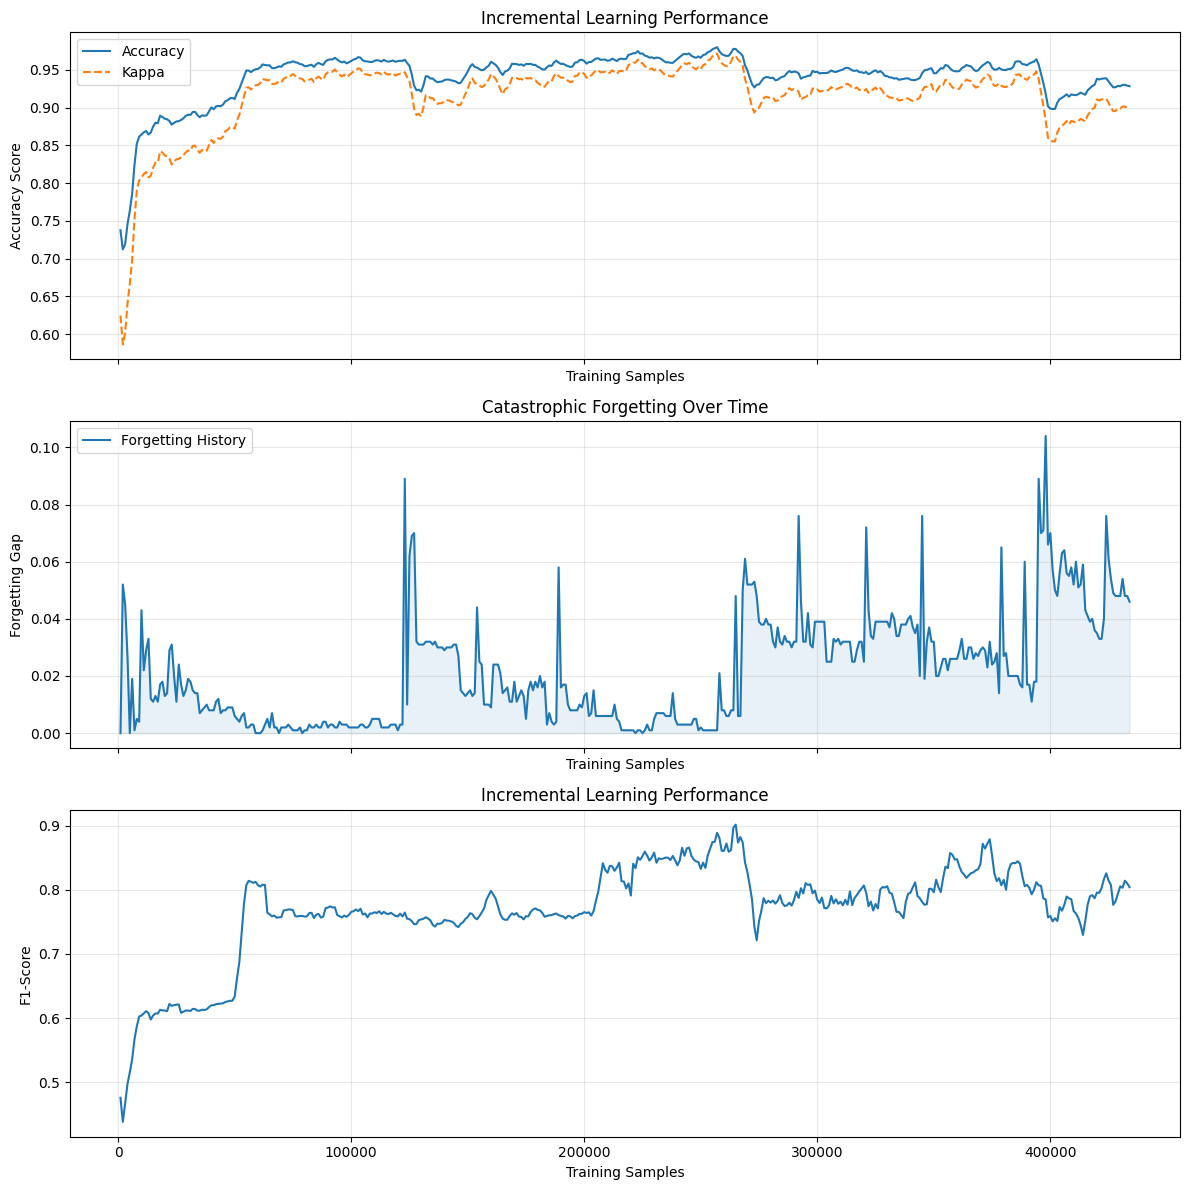

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: Accuracy & Kappa
ax1.plot(steps, accuracy_values, label='Accuracy', color='#1f77b4')
ax1.plot(steps, kappa_values, label='Kappa', color='#ff7f0e', linestyle='--')
ax1.set_ylabel("Accuracy Score")
ax1.set_xlabel("Training Samples")
ax1.set_title("Incremental Learning Performance")
ax1.grid(True, alpha=0.3)



ax1.legend()

# Plot 2: Forgetting
ax2.fill_between(steps, forgetting_history, color='#1f77b4', alpha=0.1)
ax2.plot(steps, forgetting_history, color='#1f77b4', label='Forgetting History')
ax2.set_ylabel("Forgetting Gap")
ax2.set_xlabel("Training Samples")
ax2.set_title("Catastrophic Forgetting Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1-Score
ax3.plot(steps, rolling_macro_f1_values, label='F1', color='#1f77b4')
ax3.set_ylabel("F1-Score")
ax3.set_xlabel("Training Samples")
ax3.set_title("Incremental Learning Performance")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Sudden Drift**

In [ ]:
val_set_group_0 = list(stream.iter_pandas(X_012, y_012))
val_set_group_1 = list(stream.iter_pandas(x_345, y_345))

dataset_train = stream.iter_pandas(X, y)

In [ ]:
baseline_model = preprocessing.StandardScaler() | tree.HoeffdingAdaptiveTreeClassifier(
    grace_period=50,
    delta=1e-5,
    tau=0.05,
    drift_detector=drift.ADWIN(delta=0.002),
    seed = 42
)

expert_1 = preprocessing.StandardScaler() | tree.HoeffdingAdaptiveTreeClassifier(
    grace_period=200,
    delta=1e-6,
    tau=0.08,
    leaf_prediction="mc",
    drift_detector=drift.ADWIN(delta=0.001),
    seed  = 42
)


expert_2 =  preprocessing.StandardScaler() | tree.HoeffdingAdaptiveTreeClassifier(
    grace_period=50,
    delta=1e-4,
    tau=0.1,
    leaf_prediction="nba",
    drift_detector=drift.ADWIN(delta=0.05),
    seed = 42
)

In [ ]:
Drift_Map = {
    2: ([3], [1.0]),
    3: ([2], [1.0]),

    1: ([1, 0], [0.8, 0.2]),

    0: ([0, 1], [0.8, 0.2]),

    # --- 4. STABILITY (Control Group) ---
    4: ([4], [1.0]),
    5: ([5], [1.0])
}

In [ ]:
WINDOW_SIZE = 5000

acc_metric_1 = utils.Rolling(metrics.Accuracy(), window_size=WINDOW_SIZE)
kappa_metric_1 = utils.Rolling(metrics.CohenKappa(), window_size=WINDOW_SIZE)
rolling_macro_f1 = utils.Rolling(metrics.MacroF1(), window_size=WINDOW_SIZE)


router_acc_metric_1  = utils.Rolling(metrics.Accuracy(), window_size=WINDOW_SIZE)
router_kappa_metric_1 = utils.Rolling(metrics.CohenKappa(), window_size=WINDOW_SIZE)

max_acc_g0 = 0.0
max_acc_g1 = 0.0
forgetting_history = []

accuracy_values = []
kappa_values = []
rolling_macro_f1_values = []

router_accuracy_values = []
router_kappa_values = []

timestamps_1 = []
steps = []

log_interval_1 = 1000

group_0_labels = {0, 1, 2}
group_1_labels = {3, 4, 5}

DRIFT_POINT = 200000

In [ ]:
for i, (x, y_true) in enumerate(dataset_train, start=1):

  if (i>=DRIFT_POINT):
    if y_true in Drift_Map:
      candidates, weights = Drift_Map[y_true]

      new_label = random.choices(candidates, weights, k=1)[0]
      y_true = new_label

  y_pred = predict_resilient_architecture(x)
  pred_group = baseline_model.predict_one(x)

  if y_pred is not None:
    acc_metric_1.update(y_true, y_pred)
    kappa_metric_1.update(y_true, y_pred)
    rolling_macro_f1.update(y_true, y_pred)

  if(y_true in group_0_labels):
     true_group = 0
  else:
    true_group = 1


  router_acc_metric_1.update(true_group, pred_group)
  router_kappa_metric_1.update(true_group, pred_group)

  baseline_model.learn_one(x, true_group)

  if(true_group == 0):
    expert_1.learn_one(x, y_true)
  else:
    expert_2.learn_one(x, y_true)


     # --- C. EVALUATE FORGETTING (Every 1000 steps) ---
  if i % log_interval_1 == 0:

        # 1. Test on Static Sets (Does not train, just predicts)
        # Note: Ensure val_sets are not empty before running this!

    acc_old_g0 = get_holdout_accuracy(val_set_group_0)
    acc_old_g1 = get_holdout_accuracy(val_set_group_1)


    # 2. Update Maximums (The "Peak" performance)
    if i < DRIFT_POINT:
      max_acc_g0 = max(max_acc_g0, acc_old_g0)
      max_acc_g1 = max(max_acc_g1, acc_old_g1)

    f_g0 = max(0, max_acc_g0 - acc_old_g0)
    f_g1 = max(0, max_acc_g1 - acc_old_g1)

    avg_forgetting = (f_g0 + f_g1) / 2
    forgetting_history.append(avg_forgetting)

    # 4. Logging
    steps.append(i)
    accuracy_values.append(acc_metric_1.get())
    kappa_values.append(kappa_metric_1.get())
    router_accuracy_values.append(router_acc_metric_1.get())
    router_kappa_values.append(router_kappa_metric_1.get())
    rolling_macro_f1_values.append(rolling_macro_f1.get())

  if i % 50_000 == 0:
    print(f"Step {i} | Acc: {acc_metric_1.get():.3f} | Kappa: {kappa_metric_1.get():.3f}")


Step 50000 | Acc: 0.912 | Kappa: 0.872
Step 100000 | Acc: 0.962 | Kappa: 0.945
Step 150000 | Acc: 0.948 | Kappa: 0.925
Step 200000 | Acc: 0.962 | Kappa: 0.945
Step 250000 | Acc: 0.868 | Kappa: 0.821
Step 300000 | Acc: 0.841 | Kappa: 0.783
Step 350000 | Acc: 0.854 | Kappa: 0.802
Step 400000 | Acc: 0.863 | Kappa: 0.814


In [ ]:
#  Slope Function
def get_tangent_recovery_slope(steps, acc_values, drift_point, window_steps=5000):

    steps = np.array(steps)
    acc_values = np.array(acc_values)

    mask_post_drift = steps > drift_point
    steps_post = steps[mask_post_drift]
    acc_post = acc_values[mask_post_drift]

    if len(steps_post) < 2: return None


    min_idx_local = np.argmin(acc_post)
    valley_acc = acc_post[min_idx_local]
    valley_step = steps_post[min_idx_local]


    start_measure = valley_step
    end_measure = valley_step + window_steps

    mask_window = (steps_post >= start_measure) & (steps_post <= end_measure)
    x_reg = steps_post[mask_window]
    y_reg = acc_post[mask_window]

    if len(x_reg) < 2: return None


    slope, intercept, _, _, _ = linregress(x_reg, y_reg)

    return {
        "slope_per_1k": slope * 1000,
        "valley_step": valley_step,
        "valley_acc": valley_acc,
        "plot_x": x_reg,
        "plot_y": slope * x_reg + intercept
    }

In [ ]:
accuracy_values = np.array(accuracy_values)
kappa_values = np.array(kappa_values)
rolling_macro_f1_values = np.array(rolling_macro_f1_values)
router_accuracy_values = np.array(router_accuracy_values)
router_kappa_values = np.array(router_kappa_values)
forgetting_history = np.array(forgetting_history)
steps = np.array(steps)


# A. Forgetting (Average over the whole experiment)
avg_forgetting = forgetting_history.mean()
final_forgetting = forgetting_history[-1] if len(forgetting_history) > 0 else 0.0

lowest_accuracy  = accuracy_values.min()
highest_accuracy = accuracy_values.max()
average_accuracy = accuracy_values.mean()

lowest_kappa  = kappa_values.min()
highest_kappa = kappa_values.max()
average_kappa = kappa_values.mean()

lowest_rolling_macro_f1  = rolling_macro_f1_values.min()
highest_rolling_macro_f1 = rolling_macro_f1_values.max()
average_rolling_macro_f1 = rolling_macro_f1_values.mean()

lowest_router_accuracy  = router_accuracy_values.min()
highest_router_accuracy = router_accuracy_values.max()
average_router_accuracy = router_accuracy_values.mean()

#AUC
auc_accuracy = simpson(accuracy_values, dx=1)
auc_kappa = simpson(kappa_values, dx=1)
auc_router_accuracy = simpson(router_accuracy_values, dx=1)
auc_router_kappa = simpson(router_kappa_values, dx=1)
auc_forgetting = simpson(forgetting_history, dx=1)


# Variance (Stability)
accuracy_variance = np.var(accuracy_values)


# Recovery Slop
slope_results = get_tangent_recovery_slope(steps, accuracy_values, DRIFT_POINT, window_steps=10000)

In [ ]:
print("="*40)
print("SUDDEN DRIFT BASELINE METRICS")
print("="*40)

print(f"Minimum Accuracy of Architecture:      {lowest_accuracy:.4f}")
print(f"Maximum Accuracy of Architecture:      {highest_accuracy:.4f}")
print(f"Average Accuracy of Architecture:      {average_accuracy:.4f}")

print(f"Minimum Kappa of Architecture:         {lowest_kappa:.4f}")
print(f"Maximum Kappa of Architecture:         {highest_kappa:.4f}")
print(f"Average Kappa of Architecture:         {average_kappa:.4f}")

print(f"Minimum Macro F1 of Architecture:      {lowest_rolling_macro_f1:.4f}")
print(f"Maximum Macro F1 of Architecture:      {highest_rolling_macro_f1:.4f}")
print(f"Average Macro F1 of Architecture:      {average_rolling_macro_f1:.4f}")

print(f"AUC (Accuracy):        {auc_accuracy:.2f}")
print(f"AUC (Kappa):           {auc_kappa:.2f}")
print(f"AUC (Forgetting) {auc_forgetting:.2f}")
print(f"AUC (Accuracy) of Router:        {auc_router_accuracy:.2f}")
print(f"AUC (Kappa) of Router:           {auc_router_kappa:.2f}")

print(f"Average Forgetting: {avg_forgetting:.3f}")
print(f"Final Forgetting: {final_forgetting:.3f}")
print(f"Accuracy Variance:     {accuracy_variance:.6f}")
print(f"Initial Recovery Speed: {slope_results['slope_per_1k']:.4f} accuracy points per 1k steps")

print("\nFinal Rolling Metrics")
print("Accuracy:", acc_metric_1.get())
print("Kappa:   ", kappa_metric_1.get())

print("="*40)

SUDDEN DRIFT BASELINE METRICS
Minimum Accuracy of Architecture:      0.7124
Maximum Accuracy of Architecture:      0.9670
Average Accuracy of Architecture:      0.8917
Minimum Kappa of Architecture:         0.5865
Maximum Kappa of Architecture:         0.9523
Average Kappa of Architecture:         0.8509
Minimum Macro F1 of Architecture:      0.4384
Maximum Macro F1 of Architecture:      0.8138
Average Macro F1 of Architecture:      0.7390
AUC (Accuracy):        386.20
AUC (Kappa):           368.57
AUC (Forgetting) 42.16
AUC (Accuracy) of Router:        415.79
AUC (Kappa) of Router:           397.87
Average Forgetting: 0.098
Final Forgetting: 0.159
Accuracy Variance:     0.002592
Initial Recovery Speed: 0.0063 accuracy points per 1k steps

Final Rolling Metrics
Accuracy: 0.8712
Kappa:    0.8260338505710736


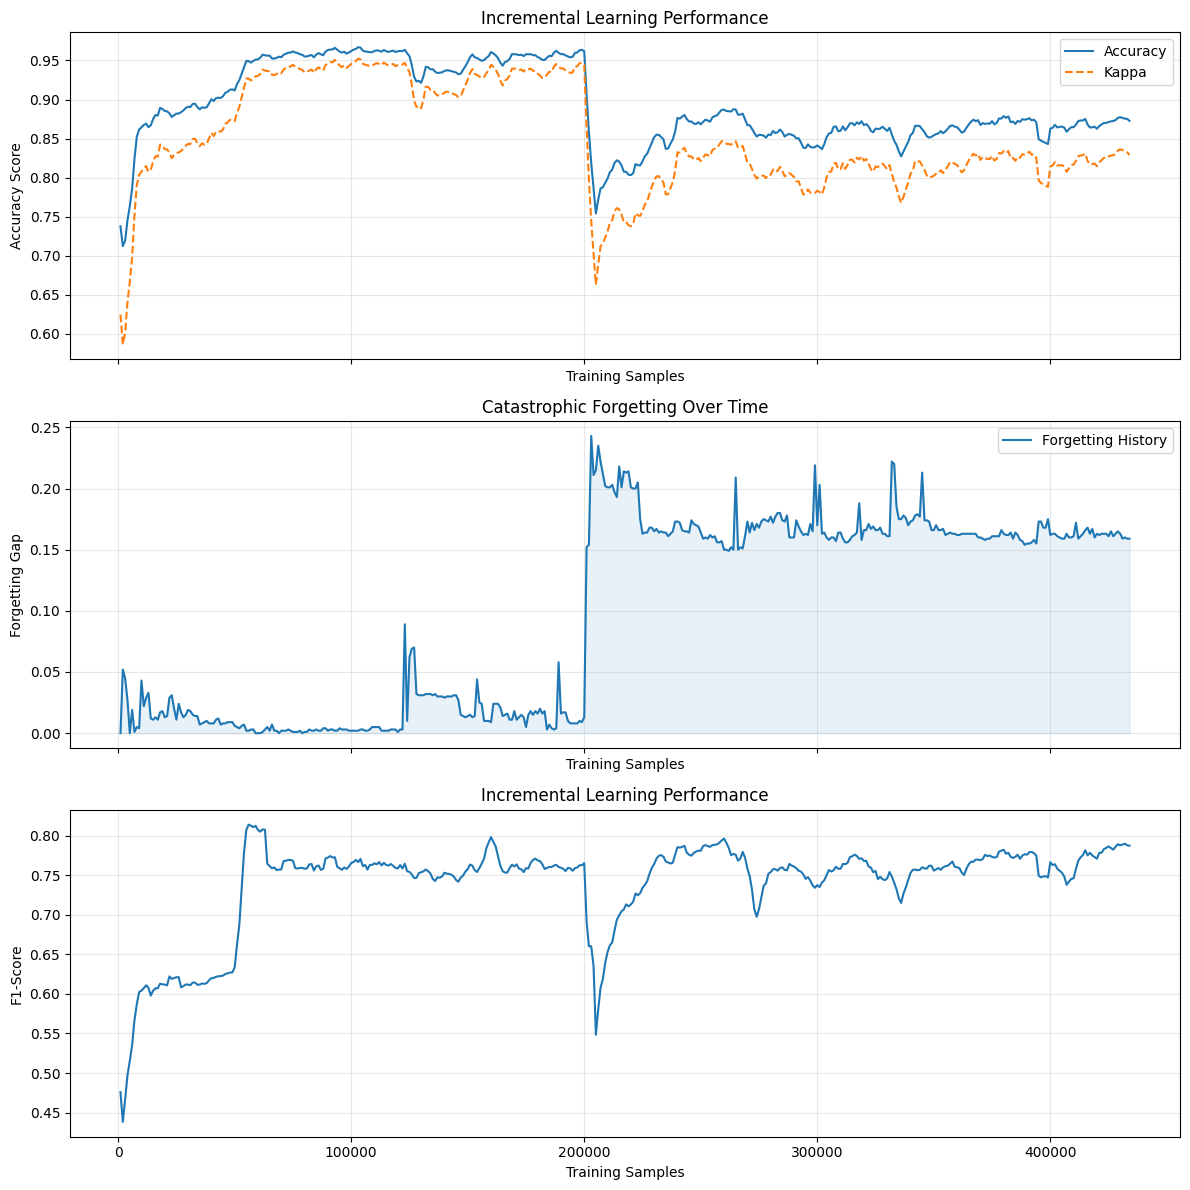

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

# Plot 1: Accuracy & Kappa
ax1.plot(steps, accuracy_values, label='Accuracy', color='#1f77b4')
ax1.plot(steps, kappa_values, label='Kappa', color='#ff7f0e', linestyle='--')
ax1.set_ylabel("Accuracy Score")
ax1.set_xlabel("Training Samples")
ax1.set_title("Incremental Learning Performance")
ax1.grid(True, alpha=0.3)



ax1.legend()

# Plot 2: Forgetting
ax2.fill_between(steps, forgetting_history, color='#1f77b4', alpha=0.1)
ax2.plot(steps, forgetting_history, color='#1f77b4', label='Forgetting History')
ax2.set_ylabel("Forgetting Gap")
ax2.set_xlabel("Training Samples")
ax2.set_title("Catastrophic Forgetting Over Time")
ax2.legend()
ax2.grid(True, alpha=0.3)

# F1-Score
ax3.plot(steps, rolling_macro_f1_values, label='F1', color='#1f77b4')
ax3.set_ylabel("F1-Score")
ax3.set_xlabel("Training Samples")
ax3.set_title("Incremental Learning Performance")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

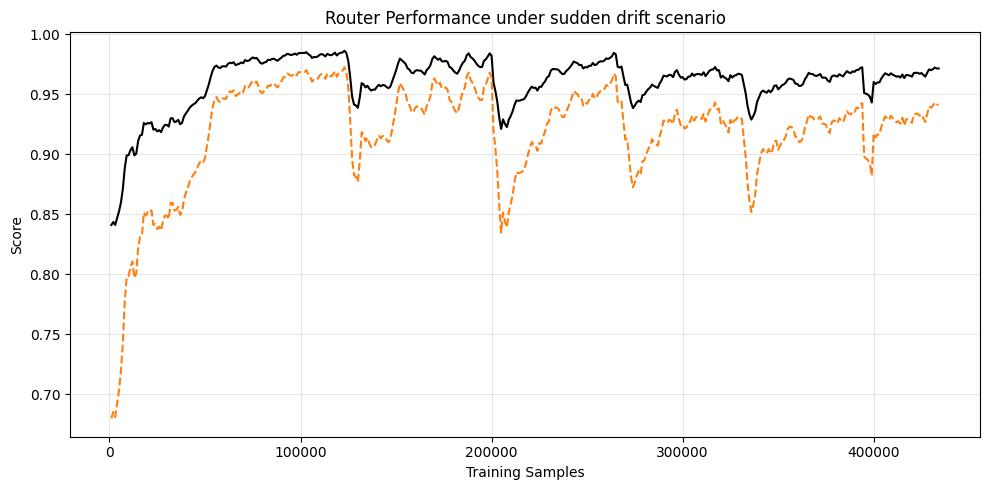

In [ ]:
# Plot 1: Accuracy & Kappa of Router
fig, (ax3) = plt.subplots(1, figsize=(10, 5), sharex=True)

ax3.plot(steps, router_accuracy_values, label='Accuracy', color='black')
ax3.plot(steps, router_kappa_values, label='Kappa', color='#ff7f0e', linestyle='--')
ax3.set_ylabel("Score")
ax3.set_xlabel("Training Samples")
ax3.set_title("Router Performance under sudden drift scenario")
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()